In [1]:
import pandas as pd
import numpy as np
import networkx as nx

import os
import re
import itertools
import pickle
import json
import datetime

from tqdm.notebook import tqdm
from collections import defaultdict

# Load interaction data

In [2]:
# actions = pd.read_csv("../source_data/actions_updated.csv")[["user_id", "jd_no", "browsed", "delivered", "satisfied"]]
# actions["label"] = actions[["browsed", "delivered", "satisfied"]].sum(axis=1)
# actions.head()

In [3]:
## We only consider candidates with at least 5 matching vacancies in the dataset
## This not only saves time, but also improves results later on
# candidate_counts = actions[actions["label"] > 0].groupby("user_id")["jd_no"].count()
# candidate_list = candidate_counts[candidate_counts >= 5].index

## Load KG

In [12]:
G = nx.DiGraph()

with open("../outputs/inferred_outputs/kg_qwen_unstructured.edgelist", encoding="utf-8") as f:
    for line in tqdm(f.readlines()):
        
        if "err:error" in line:
            print(line)
            continue
            
        s, p, o = eval(line)
        G.add_edge(s, o, edge_type=p)

  0%|          | 0/14531 [00:00<?, ?it/s]

In [13]:
# Find neighbors of each node (for quicker retrieval later on) 
all_neighbors = {}

H = G.to_undirected()

for n in tqdm(G.nodes):
    all_neighbors[n] = set(H.neighbors(n))
    
all_neighbors = {k: {i for i in v if not pd.isna(i)} for k, v in all_neighbors.items()}

  0%|          | 0/4693 [00:00<?, ?it/s]

# K random walks

In [14]:
def k_walk(G, a, b, all_neighbors, k=6, walks=100):
    sub_graph = []
            
    # Number of walks
    for _ in range(walks):
        path = ()
        
        visited = set()
        
        prev_node = a
        old = None
        
        # Length of each walk
        for _ in range(k):
            # Choose a random neighbor of our current node
            candidates = all_neighbors[prev_node] # if prev_node in all_neighbors else set(G.neighbors(prev_node))
                
            # Don't backtrack unless absolutely necessary
            if old and len(candidates) > 1:
                candidates = candidates - set([old])
            
            # If we can reach the target from the current node, 
            # do so, as long as that wouldn't create a duplicate path
            if b in candidates and (prev_node, b) not in set(sub_graph):
                next_node = b
            else:
                if candidates:
                    next_node = np.random.choice(list(candidates))
                    
                    if next_node in visited:
                        continue
                    else:
                        visited.add(next_node)                    
                else:
                    break
            
            path += (prev_node, next_node),

            # Update
            old = prev_node
            prev_node = next_node
            
            # If we found the target, store
            if next_node == b:
                sub_graph.extend(path)
                break
                
    sg = set(sub_graph)
    sg -= {(a, b)}
    sg -= {(b, a)}
                
    H = G.edge_subgraph(sg)
               
    return H

In [15]:
H.nodes()

NodeView(('jie:isco_08_44310', 'jie:polymer__guru__position_at_ipu_p_s_virum', 'jie:organic_chemistry', 'jie:isco0', 'jie:isco3122', 'jie:siemens_automation_engineer', 'jie:experience_in_automation_in_rapid_implementation', 'jie:vat_reporting', 'jie:tax_compliance_activity', 'jie:ohpt_hse_student_helper', 'jie:contract_or_project_based', 'jie:isco_08_occupation_code_25312', 'jie:isco8121', 'jid:ISCO_unit', 'jie:in_house_graphic_designer', 'jie:marine_technical_business_partner_appetiser', 'jie:vessel_performance_monitor', 'jie:isco1342', 'jie:risk_prevention_through_analysis', 'jie:skill_participation_in_interlaboratory_comparisons', 'jie:technical_graduate_program___subsurface', 'jie:training_in_time_management', 'jie:industry_manager__meat_segment_', 'jie:global_expansion_strategy', 'jie:isco52', 'jie:isco5244', 'jie:training_in_energy_storage', 'jie:isco1221', 'jie:data_steward', 'jie:data_standardization', 'jie:isco81', 'jie:isco8183', 'jie:financial_accuracy', 'jie:quality_attribu

In [30]:
ex = k_walk(H, "jie:data_steward", "jie:technical_problem_solving", all_neighbors, k=50, walks=1000)

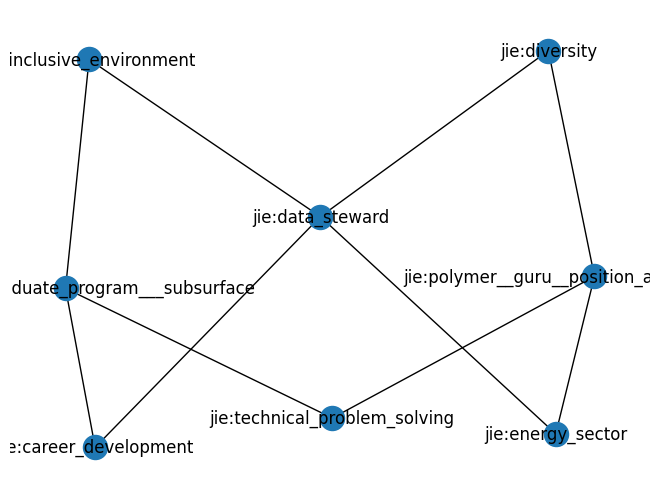

In [31]:
nx.draw_spring(ex, with_labels=True)